In [ ]:
from setup import setup, scale_features
from utils import find_best_hdbscan_params, apply_pca, apply_isolation_forest, plot_isolation_forest_pca, plot_isolation_forest_scores
import hdbscan
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import silhouette_score

In [14]:
features = setup()
scaled_features = scale_features(features)

[*********************100%***********************]  9 of 9 completed

Ticker           GLD       IWM       QQQ       SHY       SPY       TLT  \
Date                                                                     
2020-01-03  0.013269 -0.003921 -0.009160  0.000827 -0.007572  0.015400   
2020-01-06  0.010490  0.001332  0.006443 -0.000354  0.003815 -0.005679   
2020-01-07  0.003935 -0.003326 -0.000139  0.000000 -0.002812 -0.004915   
2020-01-08 -0.007502  0.003094  0.007516 -0.000472  0.005329 -0.006611   
2020-01-09 -0.005652  0.001210  0.008474  0.000118  0.006781  0.003510   

Ticker           XLE       XLF       XLK  
Date                                      
2020-01-03 -0.002971 -0.010618 -0.011243  
2020-01-06  0.007782 -0.000651  0.002382  
2020-01-07 -0.002629 -0.006508 -0.000432  
2020-01-08 -0.016472  0.006551  0.010700  
2020-01-09  0.007369  0.006183  0.011336  


In [15]:
best_size, best_samples = find_best_hdbscan_params(scaled_features)

clusterer = hdbscan.HDBSCAN(min_cluster_size=best_size, min_samples=best_samples)
regime = clusterer.fit_predict(scaled_features)

features_hdbscan = pd.DataFrame(
	scaled_features,
	index=features.index,
	columns=features.columns
)
features_hdbscan['regime'] = regime

In [16]:
#calculate silhouette score
mask_noise = regime != -1
features_hdbscan_filtered = features_hdbscan[mask_noise]
num_clusters = len(set(regime)) - (1 if -1 in regime else 0)

print(num_clusters)

if num_clusters >= 2:
    score = silhouette_score(scaled_features[mask_noise], regime[mask_noise])
    print(f'Silhouette Score: {score}')


2
Silhouette Score: 0.647419804076189


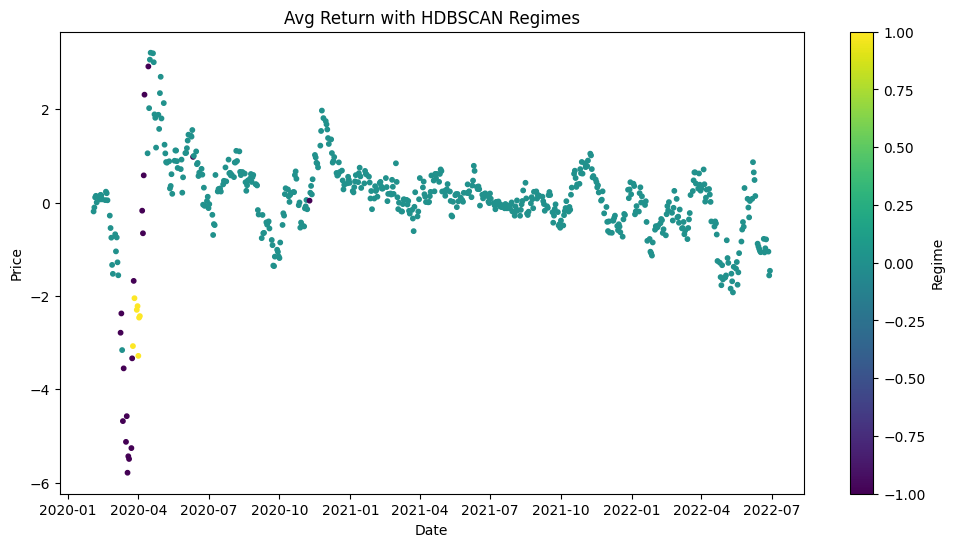

In [17]:
plt.figure(figsize=(12, 6))
plt.scatter(features.index, features_hdbscan['avg_return'].loc[features.index], c=regime, cmap='viridis', s=10)
plt.title("Avg Return with HDBSCAN Regimes")
plt.xlabel("Date")
plt.ylabel("Price")
plt.colorbar(label="Regime")
plt.show()

        PC1       PC2       PC3       PC4       PC5  regime
0  0.765681 -1.240162  0.889166  0.086548 -1.245331       1
1  0.477470 -1.449578  1.718669  0.838791 -0.893029       1
2  0.584429 -1.782110  1.610434  0.548836 -0.659167       1
3  1.225870 -1.550726  0.724696 -0.482673 -1.206859       1
4  0.890848 -1.961858  0.278291 -0.891927 -1.064379       1


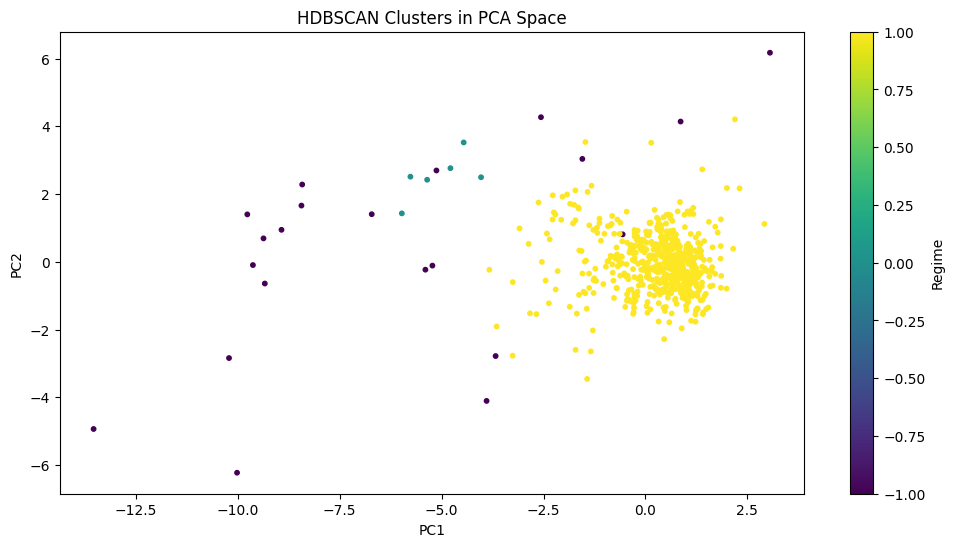

In [18]:
# Run hdbscan on PCA features
regime, pca = apply_pca(clusterer, scaled_features, 5)

features_hdbscan_pca = pd.DataFrame(
    pca,
    columns=[f'PC{i+1}' for i in range(pca.shape[1])]
)
features_hdbscan_pca['regime'] = regime

print(features_hdbscan_pca.head())

plt.figure(figsize=(12, 6))
plt.scatter(features_hdbscan_pca['PC1'], features_hdbscan_pca['PC2'], c=regime, cmap='viridis', s=10)
plt.title("HDBSCAN Clusters in PCA Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Regime")
plt.show()

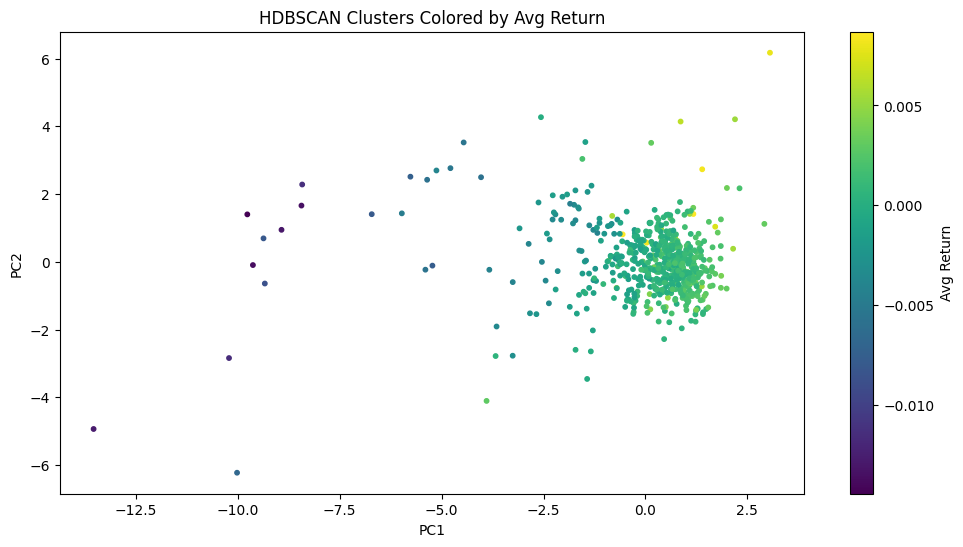

In [19]:
features_hdbscan_pca['avg_return'] = features['avg_return']
features_hdbscan_pca.groupby('regime')['avg_return'].mean()

plt.figure(figsize=(12, 6))
plt.scatter(features_hdbscan_pca['PC1'], features_hdbscan_pca['PC2'], c=features['avg_return'], cmap='viridis', s=10)
plt.title("HDBSCAN Clusters Colored by Avg Return")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Avg Return")
plt.show()

In [20]:
features_hdbscan.assign(regime=regime).groupby('regime').mean()

,volatility,avg_return,dispersion,correlation,equity_bond_spread,drawdown,vol_change
regime,,,,,,,
-1,3.247807,-2.221126,3.614557,0.169655,-0.061658,-3.069876,1.687198
0,4.849279,-2.421702,0.922247,0.606179,-0.201420,-3.032259,-0.025526
1,-0.167758,0.105472,-0.140412,-0.012414,0.004316,0.142519,-0.060824


In [21]:
features_hdbscan["future_return"] = features_hdbscan["avg_return"].shift(-1)
features_hdbscan.assign(regime=regime).groupby('regime')["future_return"].mean()

regime
-1   -2.247981
 0   -2.013038
 1    0.102721
Name: future_return, dtype: float64

In [22]:
labels, best_params, score = apply_isolation_forest(scaled_features)
print(f"Best contamination={best_params[0]}, n_estimators={best_params[1]}")
print(f"Silhouette Score: {score:.4f}")
print(f"Normal: {(labels == 1).sum()}, Anomalies: {(labels == -1).sum()}")

Best contamination=0.01, n_estimators=100
Silhouette Score: 0.7562
Normal: 600, Anomalies: 7


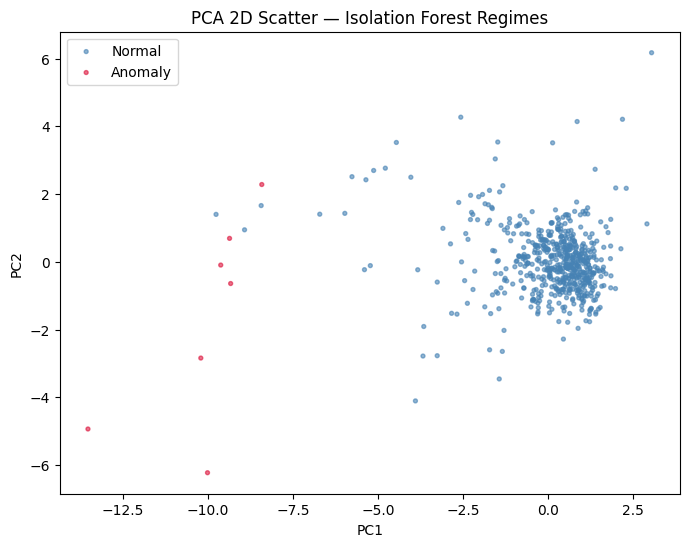

In [23]:
plot_isolation_forest_pca(scaled_features, labels)

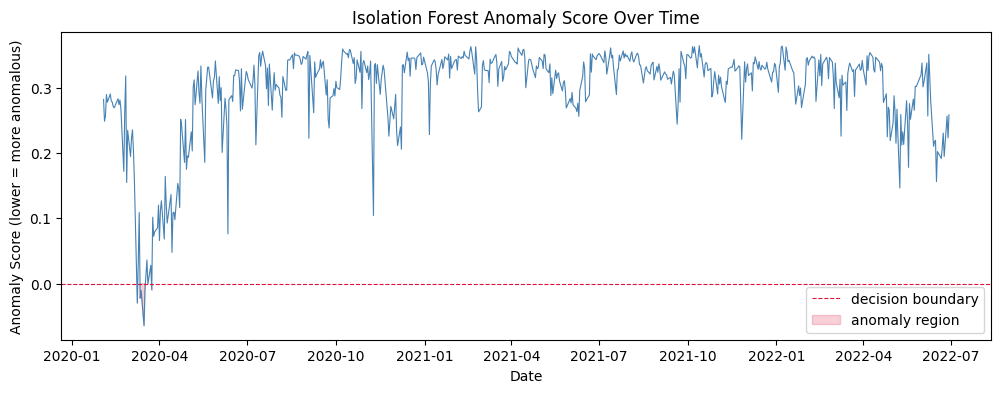

In [24]:
plot_isolation_forest_scores(scaled_features, features.index, best_params[0], best_params[1])